In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

In [2]:
def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da

def sea_mask(da):
    landsea_mask=xr.open_dataset('~/work/landseamask.nc') # mask values 0 (sea) or 1 (land)
    landsea_mask_interp = landsea_mask['mask'].interp(
    lat=da.lat,
    lon=da.lon,
    method='nearest') ##map my mask 0.5° on my 0.25° grid
    #print(landsea_mask.sel(lat=-32.25,lon=-50.25)['mask'].values)
    
    masked_da=da.where(landsea_mask_interp==1)
    return masked_da

In [3]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('~/work/data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('~/work/data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

In [4]:
def var_prepper(da, months_list, wghts_bool=True):
    ##1 Anomalies
    da_an=compute_anomaly(da)
    #print(da_an)
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    #print(da_detr)
    ##3 weight by latitude (if necessary)
    if wghts_bool==True:
        da_wght=weight_by_latitude(da_detr)
    else:
        da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season=extract_seasonal_data(da_wght,months_list)
    #print(da_season)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    da_masked=sea_mask(da_season_mean)
    print(da_masked)
    return da_masked

In [5]:
#load temperature era5 data
t_era=xr.open_dataset('~/work/data/era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 76, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan


In [6]:
##Era 5 precip data
pr_era=xr.open_dataset('~/work/data/era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

<xarray.Dataset> Size: 9MB
Dimensions:  (year: 75, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    tp       (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 9MB
Dimensions:  (year: 76, lat: 141, lon: 105)
Coordinates:
  * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
  * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
  * year     (year) int64 608B 1950 1951 1952 1953 1954 ... 2022 2023 2024 2025
Data variables:
    tp       (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan


In [7]:
#display(t_LaPlata_ssavg_SON)

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

##SON
t_whole_SON_ex=exclude_years_xr(t_whole_SON, years_to_drop)
pr_whole_SON_ex=exclude_years_xr(pr_whole_SON, years_to_drop)

##DJF
cut_years=[1950,2003,2020,2025]
t_whole_DJF_ex=exclude_years_xr(t_whole_DJF, cut_years)
pr_whole_DJF_ex=exclude_years_xr(pr_whole_DJF, cut_years)


In [8]:
##SON data
ds_SON = xr.merge([t_whole_SON_ex,pr_whole_SON_ex, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([t_whole_DJF_ex,pr_whole_DJF_ex, era_DJF_LaPlata_array])

In [54]:
def lin_model_fast(y, x_main, *x_controls):

    x_main = np.asarray(x_main).reshape(-1, 1)
    X_controls = [np.asarray(x).reshape(-1, 1) for x in x_controls]

    X = np.hstack([x_main] + X_controls)
    y = np.asarray(y)

    mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)

    if mask.sum() < 20:
        return np.nan

    coef = np.linalg.lstsq(X[mask], y[mask], rcond=None)[0]
    return coef[0]
    

def residualize(target, predictors):
    """
    Remove linear effect of predictors from target.
    """
    X = np.column_stack([p.values for p in predictors])
    y = target.values

    #mask = np.isfinite(y) & np.all(np.isfinite(X), axis=1)
    y=y #[mask]
    X=X #[mask]

    model = sm.OLS(y, X).fit()

    y_pred = model.predict(X)

    residuals = xr.full_like(target, np.nan)
    residuals.values = y - y_pred

    return residuals

def yearly_contribution(da, target, driver, condition_vars=None):
    """
    target: variable to explain
    driver: variable to assess contribution of
    condition_vars: list of vars to condition on
    """

    x = da[driver]
    y = da[target]

    #denom=x.std()**2
    if condition_vars:
        cond = [da[v] for v in condition_vars]

        x = residualize(x, cond)
        
        y = residualize(y, cond)
    cov=x*y
    denom=x.std()**2
    return cov/denom

def barplot_with_mean_line(data, driver1, target, true_reg_coef=None):

    whole_period_cov=data.sum()/(len(data)) ##do I need to divide by n-1 or n here?
    
    plt.figure(figsize=(8, 5))
    plt.bar(data['year'], data.values)
    plt.axhline(0, color='black', linestyle='-')
    plt.axhline(whole_period_cov, color='red', linestyle='--', \
                label=f'Mean Yearly Reg Coef: {whole_period_cov:.2f}')
    if true_reg_coef is not None:
        t=true_reg_coef
        plt.axhline(t, color='green', linestyle='--', \
                    label=f'Whole Period Reg Coef: {t:.2f}')
    plt.title(f'Yearly Contribution of {driver1}-->{target} link')
    plt.xlabel('Year')
    plt.ylabel('Contribution')
    plt.legend()
    plt.grid()
    plt.show()

In [55]:
def lin_model_xr(
    ds,
    indep_var1,
    dep_var,
    indep_var_list=None,
    dim="year",
    printer=True,
):


    # --- dependent variable ---
    y = ds[dep_var]

    # --- predictor list ---
    predictors = [ds[indep_var1]]

    if indep_var_list is not None:
        if isinstance(indep_var_list, list):
            predictors.extend([ds[v] for v in indep_var_list])
        else:
            predictors.append(ds[indep_var_list])

    # ---------------------------------------------------------
    # Align all variables along the regression dimension
    # ---------------------------------------------------------
    aligned = xr.align(y, *predictors, join="inner")

    y = aligned[0]
    X_vars = aligned[1:]


    X = np.column_stack([x.values for x in X_vars])
    y_vals = y.values

    mask = np.isfinite(y_vals) & np.all(np.isfinite(X), axis=1)

    X = X[mask]
    y_vals = y_vals[mask]

    model = sm.OLS(y_vals, X)
    results = model.fit()

    if printer:

        print(
            f"The effect from {indep_var1} on {dep_var}"
            f"{' conditioned on ' + str(indep_var_list) if indep_var_list else ''}"
            f" is: {results.params[0]}"
        )

        if indep_var_list is not None:

            if isinstance(indep_var_list, list):

                for i, var in enumerate(indep_var_list):

                    others = (
                        [indep_var1]
                        + indep_var_list[:i]
                        + indep_var_list[i+1:]
                    )

                    print(
                        f"The effect from {var} on {dep_var} "
                        f"conditioned on {others} is: "
                        f"{results.params[i+1]}"
                    )

            else:

                print(
                    f"The effect from {indep_var_list} on {dep_var} "
                    f"conditioned on {indep_var1} is: "
                    f"{results.params[1]}"
                )

    return results.params[0]

a=lin_model_xr(ds_SON, 'ENSO','IOD', printer=True)

The effect from ENSO on IOD is: 0.5506543942116932


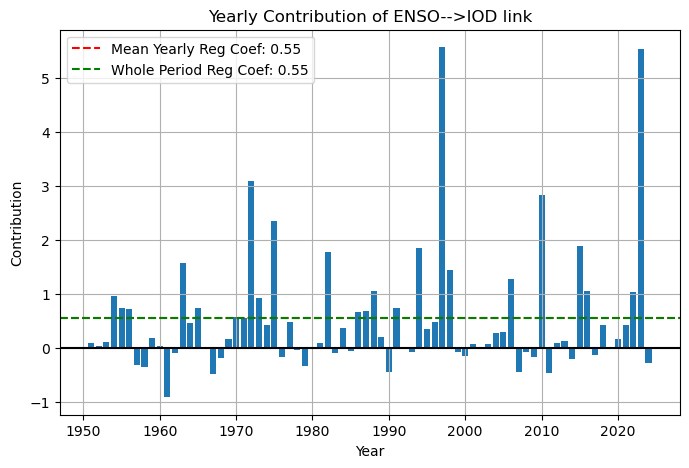

In [58]:
yearly_contrib_ENSO_IOD=yearly_contribution(ds_SON, 'IOD','ENSO')
whole_period_ENSO_IOD=lin_model_fast(ds_SON['ENSO'], ds_SON['IOD'])
barplot_with_mean_line(yearly_contrib_ENSO_IOD, driver1='ENSO', target='IOD', true_reg_coef=a)

The effect from IOD on A_SAM conditioned on ENSO is: -0.2540429346227421
The effect from ENSO on A_SAM conditioned on IOD is: -0.5711811995787874


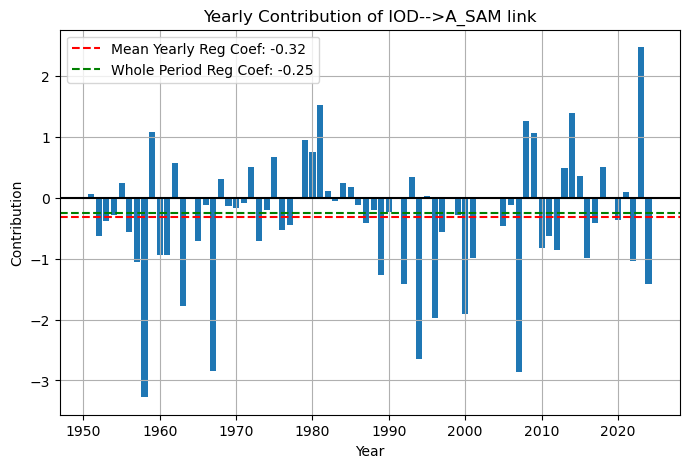

In [57]:
yearly_IOD_A_SAM_contribution_SON=yearly_contribution(ds_SON, 'IOD','A_SAM', condition_vars=['ENSO'])
whole_period_IOD_A_SAM=lin_model_fast(ds_SON['IOD'], ds_SON['A_SAM'], ds_SON['ENSO'])
b=lin_model_xr(ds_SON, 'IOD', 'A_SAM', indep_var_list='ENSO', printer=True)
barplot_with_mean_line(yearly_IOD_A_SAM_contribution_SON, driver1='IOD',\
                        target='A_SAM', true_reg_coef=b)

In [59]:
yearly_ENSO_t_contribution_SON=yearly_contribution(ds_SON, 'IOD','t_LaPlata', condition_vars=['ENSO', 'SPV', 'A_SAM', 'S_SAM'])
whole_period_IOD_t_LaPlata=lin_model_fast(ds_SON['IOD'], ds_SON['t_LaPlata'], [ds_SON['ENSO'], ds_SON['SPV'], ds_SON['A_SAM'], ds_SON['S_SAM']])
b=lin_model_xr(ds_SON, 'IOD', 't_LaPlata', indep_var_list=['ENSO', 'SPV', 'A_SAM', 'S_SAM'], printer=True)
barplot_with_mean_line(yearly_IOD_t_LaPlata_contribution_SON, driver1='IOD',\
                        target='t_LaPlata', true_reg_coef=b)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 72 and the array at index 1 has size 288